# Classification Methods on the Iris Dataset
## Math 280: Mathematical and Statistical Foundations of Data Science
### 03/04/2026

---

This notebook applies the three classification methods we have studied to Fisher's original Iris dataset — the same data he used to introduce Linear Discriminant Analysis in 1936.

We will work through:

1. **Logistic Regression** — discriminative, models $P(y \mid \mathbf{x})$ directly
2. **Linear Discriminant Analysis (LDA)** — generative, Gaussian class-conditionals with shared covariance
3. **Naive Bayes** — generative, Gaussian class-conditionals with conditional independence

For each method we will:
- Fit the model on the full dataset
- Visualise the decision boundaries using the two most discriminative features
- Evaluate performance on a held-out test set

We will then compare all three methods head-to-head using **confusion matrices**.

Finally, we zoom in on the harder **two-class problem** (versicolor vs. virginica) where the methods genuinely disagree, and introduce **ROC curves** in the setting where they are properly defined.

---
> **A note on the data.** The Iris dataset has 150 observations across three species:
> *Iris setosa*, *Iris versicolor*, and *Iris virginica*.
> Each observation has four measurements: sepal length, sepal width, petal length, and petal width (all in cm).
> Setosa is linearly separable from the other two; versicolor and virginica overlap considerably.
> This asymmetry makes it an excellent teaching dataset.


---
## Section 1: Setup and Data Exploration

Before fitting any models, we load the data and get a feel for its structure.
Understanding the data before modelling is not optional — it shapes every decision we make afterward.


In [1]:
# ── Imports ──────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc,
    RocCurveDisplay
)
from sklearn.preprocessing import label_binarize

# Consistent aesthetics throughout
sns.set_theme(style="whitegrid", font_scale=1.1)
PALETTE = ["#2196F3", "#FF9800", "#4CAF50"]   # blue, orange, green
CMAP    = ListedColormap(["#BBDEFB", "#FFE0B2", "#C8E6C9"])

print("All imports successful.")


All imports successful.


In [2]:
# ── Load the Iris dataset ────────────────────────────────────────────────
iris   = load_iris()
X      = iris.data                    # shape (150, 4)
y      = iris.target                  # 0=setosa, 1=versicolor, 2=virginica
names  = iris.target_names            # ['setosa', 'versicolor', 'virginica']
fnames = iris.feature_names           # four feature names

print(f"Dataset shape : {X.shape}")
print(f"Classes       : {list(names)}")
print(f"Features      : {fnames}")
print(f"Class counts  : {dict(zip(names, np.bincount(y)))}")


Dataset shape : (150, 4)
Classes       : ['setosa', 'versicolor', 'virginica']
Features      : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Class counts  : {'setosa': 50, 'versicolor': 50, 'virginica': 50}


### Pairwise Scatter Plot

The best first step with a multivariate dataset is to look at all pairs of features simultaneously.
This tells us which features are most discriminative and where the classes overlap.


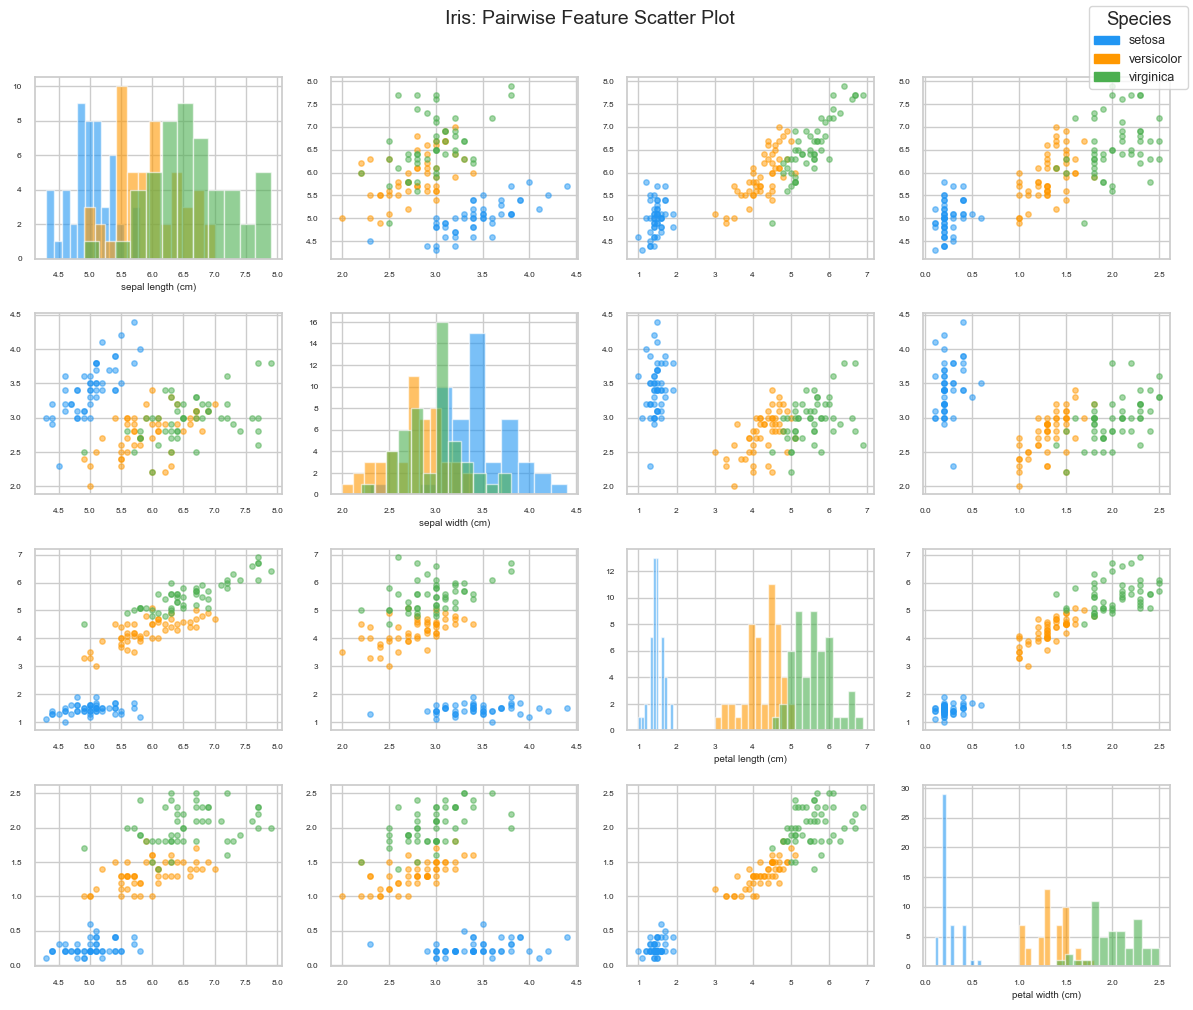

Saved: iris_pairplot.png


In [3]:
# ── Pairwise scatter plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(4, 4, figsize=(12, 10))

for i in range(4):
    for j in range(4):
        ax = axes[i, j]
        if i == j:
            # Diagonal: per-class histogram
            for k, (name, col) in enumerate(zip(names, PALETTE)):
                ax.hist(X[y == k, i], bins=12, alpha=0.6,
                        color=col, label=name)
            ax.set_xlabel(fnames[i], fontsize=7)
        else:
            for k, col in enumerate(PALETTE):
                ax.scatter(X[y == k, j], X[y == k, i],
                           c=col, alpha=0.5, s=15)
        ax.tick_params(labelsize=6)

# Single shared legend
handles = [mpatches.Patch(color=c, label=n)
           for c, n in zip(PALETTE, names)]
fig.legend(handles=handles, loc="upper right",
           fontsize=9, title="Species")
fig.suptitle("Iris: Pairwise Feature Scatter Plot", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("iris_pairplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: iris_pairplot.png")


**What to notice:**
- *Setosa* (blue) is completely separated from the other two species on petal length and petal width.
  Any reasonable classifier will classify it perfectly.
- *Versicolor* (orange) and *virginica* (green) overlap substantially, especially on sepal measurements.
  This is where the three methods will differ.
- Petal length and petal width are the most discriminative features by a wide margin.
  We will use these two for our decision boundary plots.


In [4]:
# ── Train / test split and scaling ───────────────────────────────────────
# Stratified split preserves class proportions in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Standardise: zero mean, unit variance.
# Important for logistic regression; less so for LDA/NB, but consistent.
scaler  = StandardScaler()
Xtr     = scaler.fit_transform(X_train)   # fit on train only
Xte     = scaler.transform(X_test)        # apply same transform to test

print(f"Training set : {Xtr.shape[0]} observations")
print(f"Test set     : {Xte.shape[0]} observations")
print(f"Train class counts: {dict(zip(names, np.bincount(y_train)))}")
print(f"Test  class counts: {dict(zip(names, np.bincount(y_test)))}")


Training set : 105 observations
Test set     : 45 observations
Train class counts: {'setosa': 35, 'versicolor': 35, 'virginica': 35}
Test  class counts: {'setosa': 15, 'versicolor': 15, 'virginica': 15}


---
## Section 2: Decision Boundary Visualisation

Before fitting models, we write a reusable function that plots the decision boundary
of any fitted classifier in the space of two chosen features.

The idea is simple: we create a fine grid of points covering the feature space,
predict the class for every grid point, and colour each region according to its predicted class.
The boundaries between regions are where the classifier changes its mind.


In [5]:
# ── Reusable decision boundary plotter ───────────────────────────────────
def plot_decision_boundary(clf, X_full, y_full, feat_idx, feature_names,
                           title, ax, scaler=None):
    """
    Plot the decision boundary of a fitted classifier in the 2D subspace
    defined by feat_idx = [i, j].

    Parameters
    ----------
    clf          : fitted sklearn classifier
    X_full       : full (standardised) feature matrix, shape (n, 4)
    y_full       : true labels
    feat_idx     : list of two column indices to use, e.g. [2, 3]
    feature_names: list of feature name strings
    title        : plot title
    ax           : matplotlib Axes object
    scaler       : if not None, used only to recover axis labels
    """
    fi, fj = feat_idx

    # Slice to the two chosen features
    X2 = X_full[:, feat_idx]

    # Build a dense grid over the feature range
    margin = 0.5
    x_min, x_max = X2[:, 0].min() - margin, X2[:, 0].max() + margin
    y_min, y_max = X2[:, 1].min() - margin, X2[:, 1].max() + margin
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                         np.linspace(y_min, y_max, 400))

    # Build full 4-feature grid: fix the other two features at their mean
    grid_full = np.zeros((xx.ravel().shape[0], X_full.shape[1]))
    for col in range(X_full.shape[1]):
        grid_full[:, col] = X_full[:, col].mean()
    grid_full[:, fi] = xx.ravel()
    grid_full[:, fj] = yy.ravel()

    # Predict class for every grid point
    Z = clf.predict(grid_full).reshape(xx.shape)

    # Shade the regions
    ax.contourf(xx, yy, Z, alpha=0.35, cmap=CMAP, levels=[-0.5, 0.5, 1.5, 2.5])
    ax.contour(xx, yy, Z, colors="white", linewidths=0.8, levels=[0.5, 1.5])

    # Scatter the actual data points
    for k, col in enumerate(PALETTE):
        mask = y_full == k
        ax.scatter(X2[mask, 0], X2[mask, 1],
                   c=col, edgecolors="k", linewidths=0.4,
                   s=40, label=names[k], zorder=3)

    ax.set_xlabel(feature_names[fi], fontsize=10)
    ax.set_ylabel(feature_names[fj], fontsize=10)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=8, loc="upper left")

print("plot_decision_boundary() defined.")


plot_decision_boundary() defined.


---
## Section 3: Logistic Regression

### Background

Logistic regression is a **discriminative** classifier.
It models $P(y = k \mid \mathbf{x})$ directly using the softmax function:

$$P(y = k \mid \mathbf{x}) = \frac{e^{\boldsymbol\beta_k^\top \tilde{\mathbf{x}}}}{\sum_{j=1}^K e^{\boldsymbol\beta_j^\top \tilde{\mathbf{x}}}}.$$

It makes **no assumptions** about the distribution of $\mathbf{x}$.
The parameters $\boldsymbol\beta_k$ are estimated by maximising the conditional log-likelihood
via IRLS (Iteratively Reweighted Least Squares).

Because the log-odds between any two classes are linear in $\mathbf{x}$,
the decision boundaries are hyperplanes and the decision regions are convex.

We use L2 (ridge) regularisation here, which is scikit-learn's default.
The regularisation strength is controlled by `C` — larger `C` means less regularisation.


In [6]:
# ── Fit logistic regression ───────────────────────────────────────────────
lr = LogisticRegression(
    solver="lbfgs",              # good default for small-medium data
    C=1.0,                       # inverse regularisation strength
    max_iter=200,
    random_state=42
)
lr.fit(Xtr, y_train)

# Evaluate on the held-out test set
lr_preds = lr.predict(Xte)
lr_probs = lr.predict_proba(Xte)   # shape (n_test, 3) — needed for ROC later

print("Logistic Regression — Test Set Performance")
print("=" * 45)
print(classification_report(y_test, lr_preds, target_names=names))


Logistic Regression — Test Set Performance
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



### Understanding the Classification Report

The report above gives us much more information than a single accuracy number.
Here is how to read each column, using the versicolor row as a running example.

---

#### The Core Ideas: Two Types of Error

When we classify an observation, there are two ways to be wrong:

- **False Positive (FP):** we predicted *versicolor* but the true class was something else.
- **False Negative (FN):** the true class *was* versicolor but we predicted something else.

These two error types pull in opposite directions, and precision and recall each
capture one of them.

---

#### Precision — "When we say versicolor, how often are we right?"

$$\text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}}$$

Precision asks: *of all the observations we labelled as versicolor, what fraction actually were versicolor?*

In our output, versicolor has precision **0.82**.
That means 18% of the observations we called versicolor were actually something else (virginica, in this case).

> **High precision matters when false positives are costly.**
> In a medical test, high precision means: when we tell a patient they have a disease, we are usually right.

---

#### Recall — "Of all the real versicolors, how many did we catch?"

$$\text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}$$

Recall asks: *of all the observations that truly were versicolor, what fraction did we correctly identify?*

In our output, versicolor has recall **0.93**.
That means we correctly caught 93% of the real versicolors — only 7% slipped through and were mislabelled.

> **High recall matters when false negatives are costly.**
> In a medical test, high recall means: we rarely miss someone who actually has the disease.

---

#### The Precision–Recall Trade-off

Precision and recall are in tension.
If we lower our threshold for calling something versicolor (classify more liberally),
recall goes up — we catch more true versicolors — but precision goes down — we also
grab more impostors.
If we raise the threshold (classify more conservatively),
precision goes up but recall goes down.
There is no free lunch: improving one generally costs the other.

This is exactly what the ROC curve in Section 8 traces out — it is a picture of this
trade-off as we vary the classification threshold continuously.

---

#### F1-Score — The Harmonic Mean of Precision and Recall

$$\text{F1} = \frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

The F1-score combines precision and recall into a single number.
It uses the **harmonic mean** rather than the arithmetic mean,
which penalises large imbalances between the two.
A classifier that achieves precision 1.0 and recall 0.0 gets F1 = 0, not 0.5 —
the harmonic mean forces both to be high simultaneously.

For versicolor: $F1 = 2 \times 0.82 \times 0.93 / (0.82 + 0.93) = 0.88$.

---

#### Support

The **support** column is simply the number of true observations of each class in the test set.
Here each class has 15 observations, so the split is balanced.
In unbalanced datasets, support matters a lot: a classifier that ignores a rare class
entirely can still look good on overall accuracy.

---

#### The Two Averages at the Bottom

- **Macro average:** compute precision/recall/F1 for each class separately, then take the simple average.
  Treats all classes equally regardless of how many observations each has.
- **Weighted average:** same, but weights each class by its support.
  With equal class sizes (15 each here), macro and weighted averages are identical.

---

#### Reading the Full Table

| Class | Precision | Recall | Interpretation |
|---|---|---|---|
| setosa | 1.00 | 1.00 | Perfectly classified — no errors in either direction |
| versicolor | 0.82 | 0.93 | We miss few real versicolors, but some virginica get mislabelled as versicolor |
| virginica | 0.92 | 0.80 | We rarely mislabel something as virginica, but we miss 20% of true virginicas |

Notice the asymmetry in the errors: versicolor has high recall but lower precision,
while virginica has the opposite. This tells us the model is biased toward calling
ambiguous observations *versicolor* — it under-predicts virginica.
The confusion matrix in Section 7 will make this concrete.

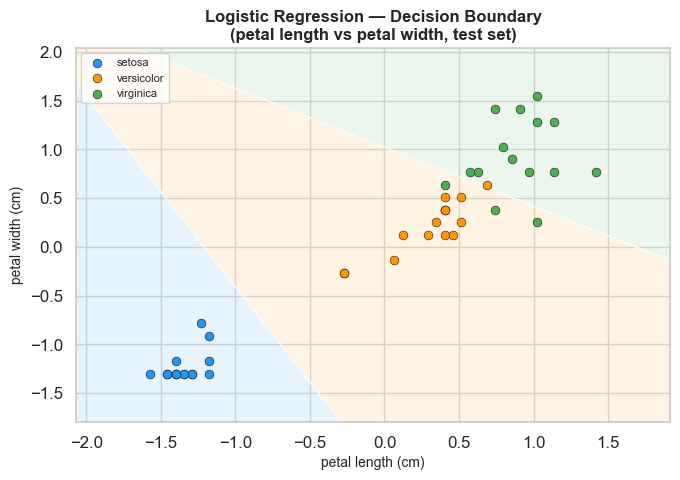

Saved: lr_boundary.png


In [7]:
# ── Decision boundary: petal length vs petal width ────────────────────────
# These are features 2 and 3 (0-indexed) and the most discriminative pair.
fig, ax = plt.subplots(figsize=(7, 5))
plot_decision_boundary(
    clf=lr,
    X_full=Xte,
    y_full=y_test,
    feat_idx=[2, 3],
    feature_names=fnames,
    title="Logistic Regression — Decision Boundary\n(petal length vs petal width, test set)",
    ax=ax
)
plt.tight_layout()
plt.savefig("lr_boundary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: lr_boundary.png")


**What to notice:**
The decision boundaries are straight lines (hyperplanes in 4D, lines in this 2D projection).
Setosa is cleanly separated in the lower-left.
The boundary between versicolor and virginica runs diagonally — logistic regression
finds the linear boundary that best separates them given the regularisation penalty.


---
## Section 4: Linear Discriminant Analysis (LDA)

### Background

LDA is a **generative** classifier.
It assumes:

$$\mathbf{x} \mid y = k \sim \mathcal{N}(\boldsymbol\mu_k, \Sigma),$$

where $\Sigma$ is **shared** across all classes.
The discriminant function for class $k$ is:

$$\delta_k(\mathbf{x}) = \boldsymbol\mu_k^\top \Sigma^{-1} \mathbf{x} - \frac{1}{2} \boldsymbol\mu_k^\top \Sigma^{-1} \boldsymbol\mu_k + \log \pi_k.$$

Classify to $\arg\max_k \, \delta_k(\mathbf{x})$.

Because the shared $\Sigma$ causes the quadratic term $\mathbf{x}^\top \Sigma^{-1} \mathbf{x}$
to cancel when comparing any two classes, the boundaries are again linear hyperplanes.

All parameters ($\hat{\boldsymbol\mu}_k$, $\hat{\Sigma}$, $\hat{\pi}_k$) are estimated in **closed form** —
no iterative algorithm required.

The equivalence theorem tells us that in population, when the Gaussian assumptions hold,
LDA and logistic regression find the **same boundary**.
In finite samples they will differ.


In [8]:
# ── Fit LDA ───────────────────────────────────────────────────────────────
lda = LinearDiscriminantAnalysis(solver="svd")   # SVD: numerically stable
lda.fit(Xtr, y_train)

lda_preds = lda.predict(Xte)
lda_probs = lda.predict_proba(Xte)

print("LDA — Test Set Performance")
print("=" * 45)
print(classification_report(y_test, lda_preds, target_names=names))


LDA — Test Set Performance
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.94      1.00      0.97        15
   virginica       1.00      0.93      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



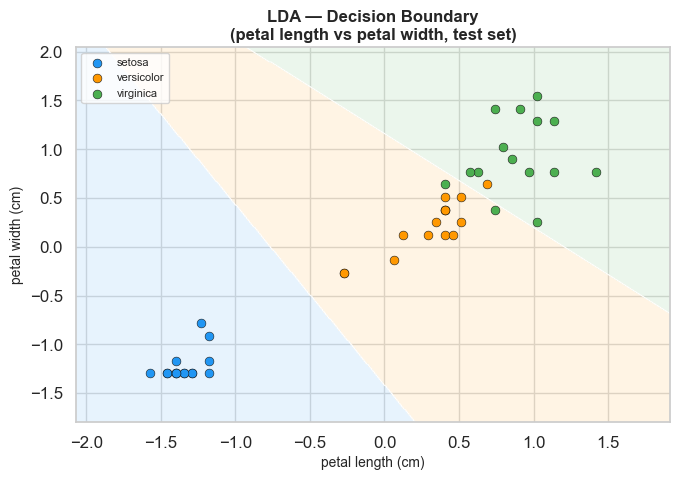

Saved: lda_boundary.png


In [9]:
# ── Decision boundary ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
plot_decision_boundary(
    clf=lda,
    X_full=Xte,
    y_full=y_test,
    feat_idx=[2, 3],
    feature_names=fnames,
    title="LDA — Decision Boundary\n(petal length vs petal width, test set)",
    ax=ax
)
plt.tight_layout()
plt.savefig("lda_boundary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: lda_boundary.png")


**What to notice:**
LDA's boundary is also linear, for the same algebraic reason as logistic regression —
the shared covariance cancels the quadratic term.
Compare carefully with the logistic regression boundary above.
They are similar but not identical, because the two methods estimate $\boldsymbol\beta^*$
via different routes (discriminants vs. conditional likelihood).


---
## Section 5: Gaussian Naive Bayes

### Background

Gaussian Naive Bayes is also a **generative** classifier, but it makes a stronger assumption:
given the class, the features are **conditionally independent**:

$$P(\mathbf{x} \mid y = k) = \prod_{j=1}^{d} P(x_j \mid y = k),
\quad x_j \mid y = k \sim \mathcal{N}(\mu_{jk}, \sigma_{jk}^2).$$

This is equivalent to LDA with a **diagonal** covariance matrix —
all off-diagonal (correlation) terms are forced to zero.
It estimates $d \times K$ scalar parameters instead of a full $d \times d$ matrix.

The log-posterior has a clean additive form:

$$\log P(y = k \mid \mathbf{x}) \propto \log \pi_k + \sum_{j=1}^d \log P(x_j \mid y = k).$$

Each feature votes independently for each class.

Because Naive Bayes allows **class-specific variances** $\sigma_{jk}^2$,
its decision boundaries can be **quadratic** — curved rather than straight lines.
Watch for this in the boundary plot below.


In [10]:
# ── Fit Gaussian Naive Bayes ──────────────────────────────────────────────
gnb = GaussianNB()
gnb.fit(Xtr, y_train)

gnb_preds = gnb.predict(Xte)
gnb_probs = gnb.predict_proba(Xte)

print("Gaussian Naive Bayes — Test Set Performance")
print("=" * 45)
print(classification_report(y_test, gnb_preds, target_names=names))


Gaussian Naive Bayes — Test Set Performance
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



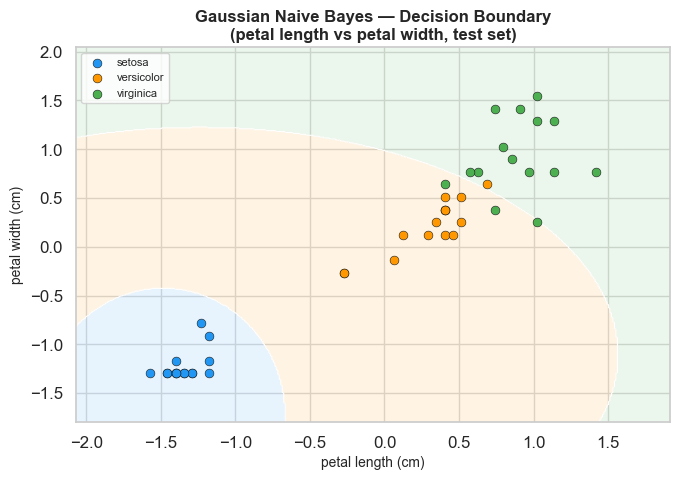

Saved: gnb_boundary.png


In [11]:
# ── Decision boundary ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
plot_decision_boundary(
    clf=gnb,
    X_full=Xte,
    y_full=y_test,
    feat_idx=[2, 3],
    feature_names=fnames,
    title="Gaussian Naive Bayes — Decision Boundary\n(petal length vs petal width, test set)",
    ax=ax
)
plt.tight_layout()
plt.savefig("gnb_boundary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: gnb_boundary.png")


**What to notice:**
Unlike LDA and logistic regression, Naive Bayes can produce **curved boundaries**.
This happens because the class-specific variances $\sigma_{jk}^2$ differ between versicolor
and virginica — the quadratic term no longer cancels.
Compare the boundary between the orange and green regions with the corresponding boundary in the LDA plot.


---
## Section 6: Side-by-Side Comparison of Decision Boundaries

Putting all three boundaries on the same figure makes the differences easy to see.


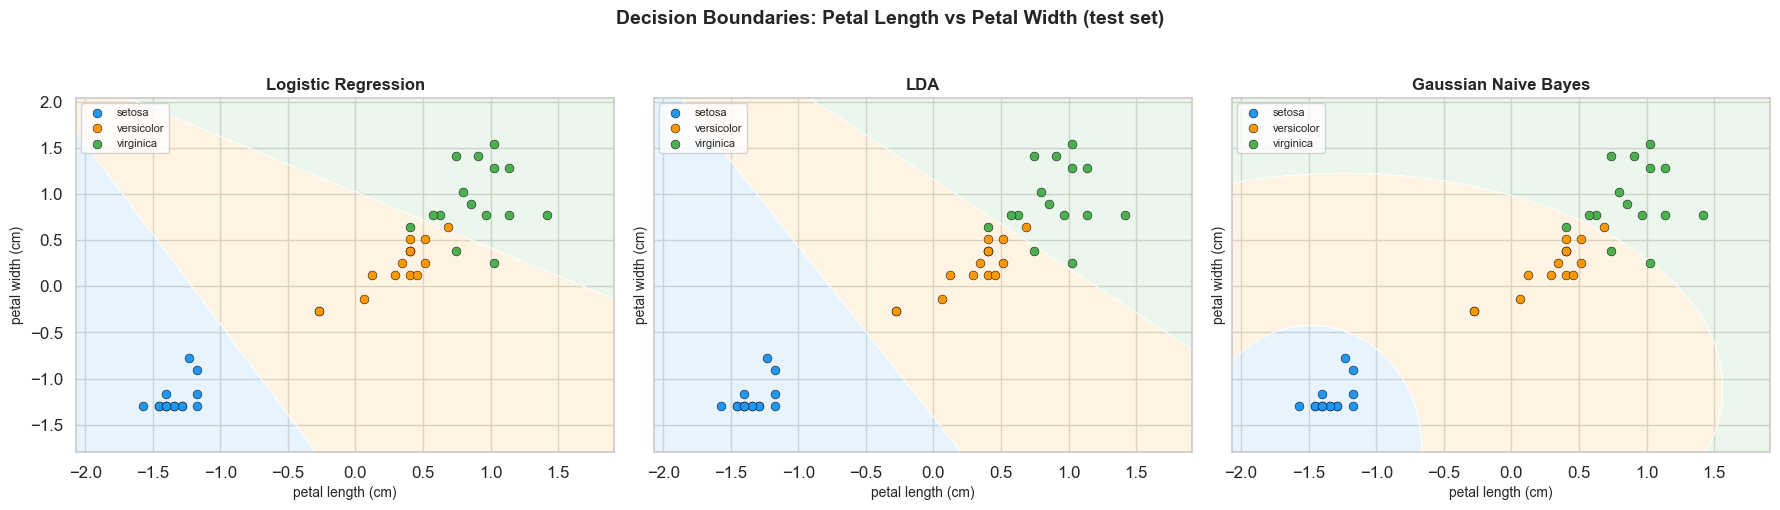

Saved: all_boundaries.png


In [12]:
# ── Side-by-side: all three methods ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

configs = [
    (lr,  "Logistic Regression"),
    (lda, "LDA"),
    (gnb, "Gaussian Naive Bayes"),
]

for ax, (clf, title) in zip(axes, configs):
    plot_decision_boundary(
        clf=clf,
        X_full=Xte,
        y_full=y_test,
        feat_idx=[2, 3],
        feature_names=fnames,
        title=title,
        ax=ax
    )

fig.suptitle("Decision Boundaries: Petal Length vs Petal Width (test set)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("all_boundaries.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: all_boundaries.png")


---
## Section 7: Confusion Matrices

A confusion matrix shows exactly which classes are being misclassified as which.
For three classes this is a $3 \times 3$ table:
- The diagonal entries are correct classifications.
- Off-diagonal entry $(i, j)$ is the number of class-$i$ observations predicted as class $j$.

This is richer than a single accuracy number.
It tells us *which* mistakes the classifier is making — and for Iris,
the interesting question is whether it confuses versicolor with virginica
(which overlap) or makes the easier mistakes involving setosa (which does not overlap with either).

> **Note on ROC curves for three classes.**
> A standard ROC curve requires a binary problem: one positive class, one negative class,
> one threshold, one true positive rate, one false positive rate.
> For $K = 3$ classes this is not directly defined.
> The standard extension is **one-vs-rest (OVR)**: treat each class as the positive class
> in turn and draw three separate ROC curves.
> We do this in Section 8 for the full three-class problem,
> and then properly in Section 9 for the binary versicolor vs. virginica problem.


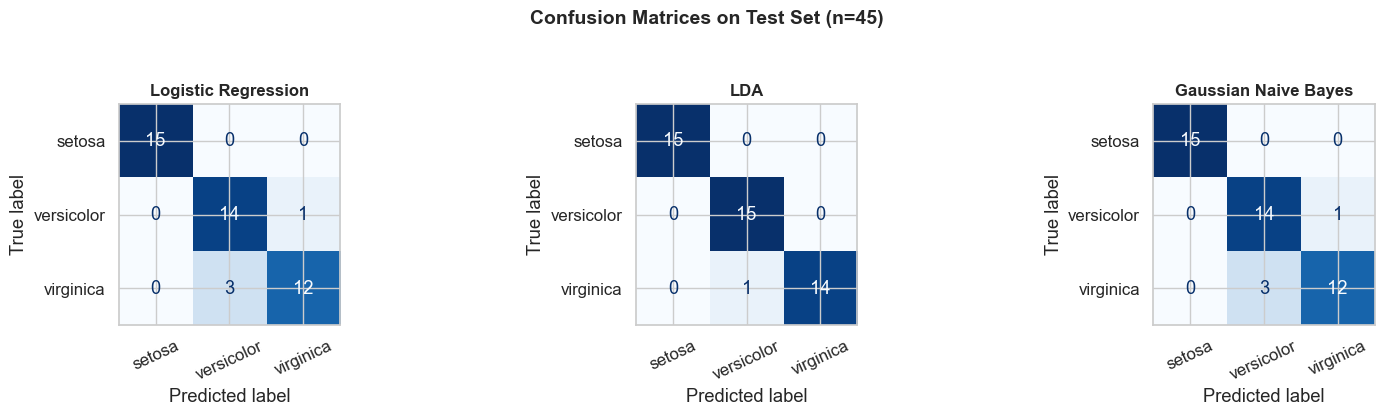

Saved: confusion_matrices.png


In [13]:
# ── Confusion matrices for all three methods ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

all_preds = [
    (lr_preds,  "Logistic Regression"),
    (lda_preds, "LDA"),
    (gnb_preds, "Gaussian Naive Bayes"),
]

for ax, (preds, title) in zip(axes, all_preds):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=names)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.tick_params(axis="x", rotation=25)

fig.suptitle("Confusion Matrices on Test Set (n=45)",
             fontsize=14, fontweight="bold", y=1.04)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrices.png")


In [14]:
# ── Accuracy summary ──────────────────────────────────────────────────────
from sklearn.metrics import accuracy_score

print("Method                  | Test Accuracy")
print("-" * 40)
for preds, title in all_preds:
    acc = accuracy_score(y_test, preds)
    print(f"{title:<25}| {acc:.3f}  ({int(acc*len(y_test))}/{len(y_test)} correct)")


Method                  | Test Accuracy
----------------------------------------
Logistic Regression      | 0.911  (41/45 correct)
LDA                      | 0.978  (44/45 correct)
Gaussian Naive Bayes     | 0.911  (41/45 correct)


**What to notice:**
- All three methods classify setosa (row 0) perfectly — it is linearly separable.
- The errors are almost entirely confined to the versicolor / virginica boundary.
- Check whether any method makes systematically different errors on this boundary.
  Does Naive Bayes misclassify more in one direction than the other?
  Does LDA do better or worse than logistic regression?


---
## Section 8: One-vs-Rest ROC Curves (Three-Class)

As noted above, we extend ROC to three classes using the **one-vs-rest** strategy.
For each class $k$ we ask: how well does the model's predicted probability
$\hat{P}(y = k \mid \mathbf{x})$ discriminate class $k$ from the other two combined?

Each curve plots the true positive rate (sensitivity) against the false positive rate (1 - specificity)
as we vary the probability threshold.
The **area under the curve (AUC)** summarises this: AUC = 1 is perfect, AUC = 0.5 is random.

Because setosa is perfectly separated, all three methods will achieve AUC $\approx 1$ for that class.
The interesting comparison is the AUC for versicolor and virginica.


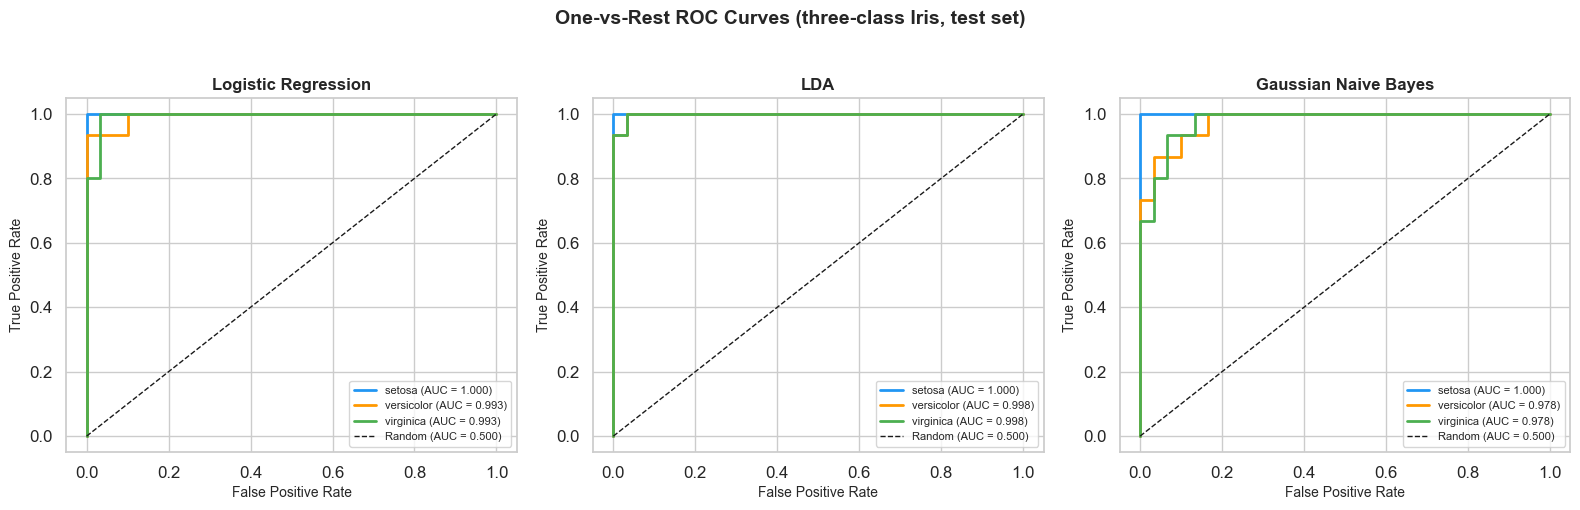

Saved: roc_3class.png


In [15]:
# ── One-vs-rest ROC curves ────────────────────────────────────────────────
# Binarise the labels: shape (n_test, 3), one column per class
y_bin = label_binarize(y_test, classes=[0, 1, 2])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

method_probs = [
    (lr_probs,  "Logistic Regression"),
    (lda_probs, "LDA"),
    (gnb_probs, "Gaussian Naive Bayes"),
]

for ax, (probs, method_name) in zip(axes, method_probs):
    for k, (species, col) in enumerate(zip(names, PALETTE)):
        # ROC for class k vs all others
        fpr, tpr, _ = roc_curve(y_bin[:, k], probs[:, k])
        roc_auc     = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=col, lw=2,
                label=f"{species} (AUC = {roc_auc:.3f})")

    # Diagonal reference line: random classifier
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC = 0.500)")
    ax.set_xlabel("False Positive Rate", fontsize=10)
    ax.set_ylabel("True Positive Rate", fontsize=10)
    ax.set_title(method_name, fontsize=12, fontweight="bold")
    ax.legend(fontsize=8, loc="lower right")

fig.suptitle("One-vs-Rest ROC Curves (three-class Iris, test set)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("roc_3class.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: roc_3class.png")


---
## Section 9: The Hard Problem — Versicolor vs. Virginica

### Why This Subproblem Is More Interesting

Setosa is trivially separated from the other two classes.
The real test of each method is how it handles the **versicolor vs. virginica** boundary,
where the two classes overlap in all four features.

In this binary subproblem, the ROC curve is properly and unambiguously defined:
- **Positive class**: virginica (label 1 in our binary encoding)
- **Negative class**: versicolor (label 0)
- We vary the threshold on $\hat{P}(\text{virginica} \mid \mathbf{x})$ and trace out the curve.

This is where we expect the three methods to show real differences.


In [16]:
# ── Extract versicolor vs virginica ───────────────────────────────────────
# Keep only observations from classes 1 and 2
mask   = y != 0
X_bin  = X[mask]                  # raw features
y_bin2 = (y[mask] == 2).astype(int)   # virginica = 1, versicolor = 0

print(f"Binary dataset: {X_bin.shape[0]} observations")
print(f"  versicolor (0): {(y_bin2==0).sum()}")
print(f"  virginica  (1): {(y_bin2==1).sum()}")


Binary dataset: 100 observations
  versicolor (0): 50
  virginica  (1): 50


In [17]:
# ── Train / test split and scaling ───────────────────────────────────────
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_bin, y_bin2, test_size=0.30, random_state=42, stratify=y_bin2
)
scaler2 = StandardScaler()
Xtr2    = scaler2.fit_transform(X_train2)
Xte2    = scaler2.transform(X_test2)

print(f"Train: {Xtr2.shape[0]}  |  Test: {Xte2.shape[0]}")


Train: 70  |  Test: 30


In [18]:
# ── Fit all three methods on the binary problem ───────────────────────────
lr2  = LogisticRegression(solver="lbfgs", C=1.0, max_iter=200, random_state=42)
lda2 = LinearDiscriminantAnalysis(solver="svd")
gnb2 = GaussianNB()

lr2.fit(Xtr2, y_train2)
lda2.fit(Xtr2, y_train2)
gnb2.fit(Xtr2, y_train2)

bin_names = ["versicolor", "virginica"]

for clf, name in [(lr2, "Logistic Regression"),
                  (lda2, "LDA"),
                  (gnb2, "Gaussian Naive Bayes")]:
    preds = clf.predict(Xte2)
    print(f"\n{name}")
    print("-" * 35)
    print(classification_report(y_test2, preds, target_names=bin_names))



Logistic Regression
-----------------------------------
              precision    recall  f1-score   support

  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30


LDA
-----------------------------------
              precision    recall  f1-score   support

  versicolor       1.00      1.00      1.00        15
   virginica       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Gaussian Naive Bayes
-----------------------------------
              precision    recall  f1-score   support

  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy              

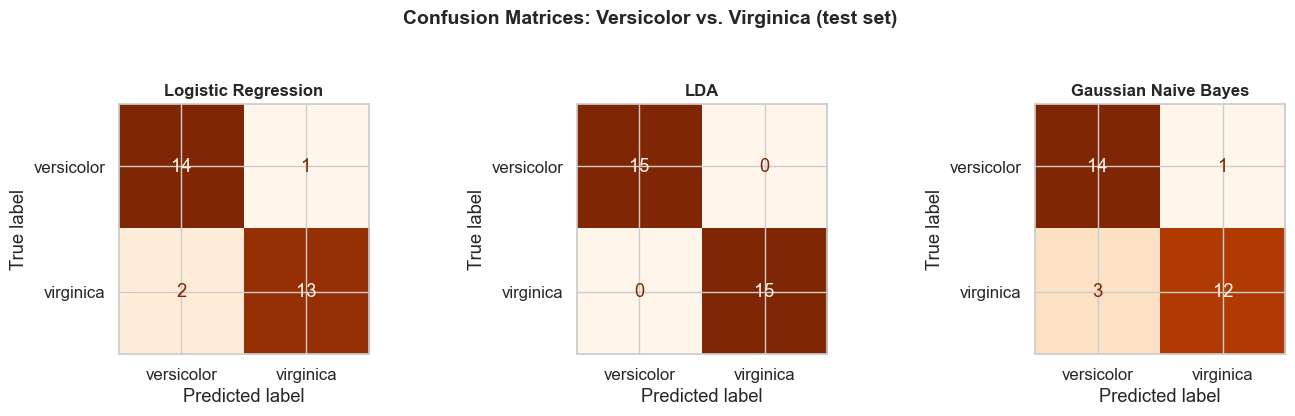

In [19]:
# ── Confusion matrices: binary problem ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

bin_clfs = [
    (lr2,  "Logistic Regression"),
    (lda2, "LDA"),
    (gnb2, "Gaussian Naive Bayes"),
]

for ax, (clf, title) in zip(axes, bin_clfs):
    cm   = confusion_matrix(y_test2, clf.predict(Xte2))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=bin_names)
    disp.plot(ax=ax, colorbar=False, cmap="Oranges")
    ax.set_title(title, fontsize=12, fontweight="bold")

fig.suptitle("Confusion Matrices: Versicolor vs. Virginica (test set)",
             fontsize=14, fontweight="bold", y=1.04)
plt.tight_layout()
plt.savefig("confusion_binary.png", dpi=150, bbox_inches="tight")
plt.show()


---
### Proper ROC Curves: Binary Classification

Now that we have a genuine binary problem, we can draw ROC curves exactly as defined.

Each curve traces the trade-off between:
- **True Positive Rate (TPR / Sensitivity)**: of all actual virginica, what fraction do we correctly identify?
- **False Positive Rate (FPR / 1 - Specificity)**: of all actual versicolor, what fraction do we incorrectly call virginica?

As we lower the classification threshold (requiring less evidence to call something virginica),
both TPR and FPR increase.
The ROC curve traces this path from the bottom-left (threshold = 1, predict nothing)
to the top-right (threshold = 0, predict everything).

A good classifier hugs the top-left corner.
The AUC (area under the curve) summarises this in a single number between 0.5 (random) and 1 (perfect).


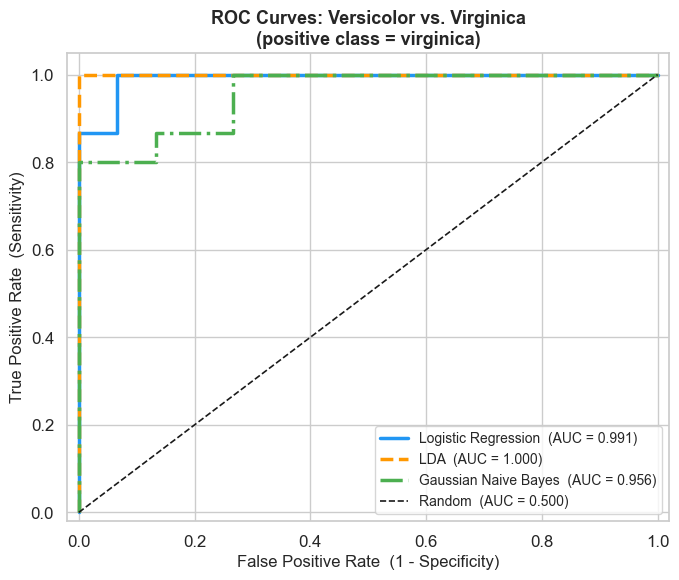

Saved: roc_binary.png


In [20]:
# ── ROC curves: versicolor vs virginica ───────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

roc_styles = [
    (lr2,  "Logistic Regression", "#2196F3", "-"),
    (lda2, "LDA",                 "#FF9800", "--"),
    (gnb2, "Gaussian Naive Bayes","#4CAF50", "-."),
]

for clf, label, col, ls in roc_styles:
    # Probability of virginica (class 1) for each test observation
    prob_pos = clf.predict_proba(Xte2)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test2, prob_pos)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=col, lw=2.5, linestyle=ls,
            label=f"{label}  (AUC = {roc_auc:.3f})")

# Random classifier reference
ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="Random  (AUC = 0.500)")

ax.set_xlabel("False Positive Rate  (1 - Specificity)", fontsize=12)
ax.set_ylabel("True Positive Rate  (Sensitivity)",      fontsize=12)
ax.set_title("ROC Curves: Versicolor vs. Virginica\n(positive class = virginica)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10, loc="lower right")
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])

plt.tight_layout()
plt.savefig("roc_binary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: roc_binary.png")


---
## Section 10: Summary and Discussion

### What We Observed

| Method | 3-class accuracy | Versicolor/Virginica errors | Boundary shape |
|---|---|---|---|
| Logistic Regression | see above | see confusion matrix | Linear |
| LDA | see above | see confusion matrix | Linear |
| Gaussian Naive Bayes | see above | see confusion matrix | Potentially curved |

### Key Takeaways

**1. Setosa is always easy.**
All three methods classify setosa perfectly.
This reflects the linear separability of setosa in petal space —
any reasonable linear boundary will do it.

**2. The interesting action is on the versicolor/virginica boundary.**
This is where the methods differ, and where the choice of model matters.
The confusion matrices show exactly which direction errors go.

**3. LDA and logistic regression produce similar boundaries, not identical ones.**
The equivalence theorem says they converge to the same boundary in population.
On a finite dataset of 105 training observations they estimate slightly differently.

**4. Naive Bayes can produce curved boundaries.**
Because it fits class-specific variances rather than a shared covariance matrix,
the quadratic term does not cancel.
Look at the boundary plot: is it noticeably curved compared to LDA?

**5. ROC curves require care with multiple classes.**
The one-vs-rest approach works but produces three curves per method.
The binary subproblem gives a clean, unambiguous ROC with a single interpretable curve per method.

### Suggested Extensions

- **Repeat with all four features** (remove the 2D projection) and report test accuracy.
  Does the ranking of the three methods change?
- **Try QDA** (`QuadraticDiscriminantAnalysis`) and compare its boundary to Naive Bayes.
  Both allow curved boundaries but for different reasons.
- **Vary the train/test split** (e.g. 50/50, 80/20) and observe how the accuracy estimates change.
  Which method is most stable?
- **Add regularisation to LDA** (`LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')`)
  and compare to unregularised LDA.
